In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
print(tf.__version__)

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix

base_dir = "/content/drive/MyDrive/AI/Train_Test_Valid"

train_dir = os.path.join(base_dir, "Train")
valid_dir = os.path.join(base_dir, "valid")
test_dir  = os.path.join(base_dir, "test")

2.20.0


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
def audit_dataset(directory, expected_size=(224, 224)):
    total_images = 0
    mismatched_sizes = []
    corrupted_files = []

    print(f"Starting audit in: {directory}")

    for subdir, dirs, files in os.walk(directory):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                total_images += 1
                file_path = os.path.join(subdir, file)

                try:
                    with Image.open(file_path) as img:
                        # Check resolution
                        if img.size != expected_size:
                            mismatched_sizes.append((file, img.size))
                except Exception as e:
                    corrupted_files.append(file_path)

    # --- Final Report ---
    print(f"\nAudit Complete!")
    print(f"Total images scanned: {total_images}")
    print(f"Images with wrong resolution: {len(mismatched_sizes)}")
    print(f"Corrupted files found: {len(corrupted_files)}")

    if mismatched_sizes:
      print(f"\nTotal mismatched images: {len(mismatched_sizes)}")

    print("\nFirst 10 mismatches (File, Actual Size):")
    for name, size in mismatched_sizes:
      print(f"- {name}: {size}")

# Run it on your training folder
audit_dataset(train_dir)

Starting audit in: /content/drive/MyDrive/AI/Train_Test_Valid/Train

Audit Complete!
Total images scanned: 900
Images with wrong resolution: 268
Corrupted files found: 0

Total mismatched images: 268

First 10 mismatches (File, Actual Size):
- aug-43-03.jpg: (179, 179)
- aug-19-25.jpg: (179, 179)
- aug-42-02.jpg: (179, 179)
- aug-38-47.jpg: (179, 179)
- aug-36-45.jpg: (179, 179)
- aug-31-38.jpg: (179, 179)
- aug-104-29.jpg: (179, 179)
- aug-25-32.JPG: (179, 179)
- aug-12-15.jpg: (179, 179)
- aug-35-42.jpg: (179, 179)
- aug-102-27.jpg: (179, 179)
- aug-33-40.jpg: (179, 179)
- aug-39-48.jpg: (179, 179)
- aug-23-30.jpg: (179, 179)
- aug-20-27.jpg: (179, 179)
- aug-24-31.jpg: (179, 179)
- aug-28-35.jpg: (179, 179)
- aug-105-30.jpg: (179, 179)
- aug-18-24.jpg: (179, 179)
- aug-97-20.jpg: (179, 179)
- aug-89-10.jpg: (179, 179)
- aug-53-15.jpg: (179, 179)
- aug-73-39.JPG: (179, 179)
- aug-81-49.jpg: (179, 179)
- aug-78-46.jpg: (179, 179)
- aug-59-24.jpg: (179, 179)
- aug-44-04.jpg: (179, 179)

In [4]:
def validate_images(directory):
    bad_images = []
    for subdir, dirs, files in os.walk(directory):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                try:
                    img = Image.open(os.path.join(subdir, file))
                    img.verify()
                except (IOError, SyntaxError) as e:
                    print(f'Bad file: {file}')
                    bad_images.append(os.path.join(subdir, file))
    return bad_images

errors = validate_images(train_dir)
if errors:
    print(f"Total bad images: {len(errors)}")
    print(errors)
else:
    print("No coorupted images found.")

No coorupted images found.


## Part A — CNN FROM SCRATCH

### SECTION 1 — DATA UNDERSTANDING & VISUALIZATION

### Dataset Description

This dataset consists of images of various jellyfish species, intended for image classification tasks. Given its relatively small size, careful consideration of augmentation, regularization, and potentially transfer learning will be crucial to achieve good generalization performance.


In [5]:
# Function to count images and get class names
def count_images_and_get_classes(directory):
    image_count = 0
    class_names = []
    for root, dirs, files in os.walk(directory):
        # Get class names from subdirectories within the main directory
        if root == directory:
            class_names = sorted([d for d in dirs if not d.startswith('.')]) # Exclude hidden dirs

        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                image_count += 1
    return image_count, class_names

# Count images in each split
train_count, train_classes = count_images_and_get_classes(train_dir)
valid_count, valid_classes = count_images_and_get_classes(valid_dir)
test_count, test_classes = count_images_and_get_classes(test_dir)

print(f"Total images in training set: {train_count}")
print(f"Total images in validation set: {valid_count}")
print(f"Total images in test set: {test_count}")
print(f"Total images in dataset: {train_count + valid_count + test_count}")

print(f"\nClasses in training set: {train_classes}")


Total images in training set: 900
Total images in validation set: 39
Total images in test set: 40
Total images in dataset: 979

Classes in training set: ['Moon_jellyfish', 'barrel_jellyfish', 'blue_jellyfish', 'compass_jellyfish', 'lions_mane_jellyfish', 'mauve_stinger_jellyfish']


### Class Distribution

Understanding the distribution of images across different classes is important to identify potential class imbalances.

Training Set Class Distribution:


,Count
Class,
barrel_jellyfish,150
lions_mane_jellyfish,150
blue_jellyfish,150
compass_jellyfish,150
mauve_stinger_jellyfish,150
Moon_jellyfish,150



Validation Set Class Distribution:


,Count
Class,
barrel_jellyfish,5
compass_jellyfish,7
lions_mane_jellyfish,7
mauve_stinger_jellyfish,7
blue_jellyfish,7
Moon_jellyfish,6



Test Set Class Distribution:


,Count
Class,
barrel_jellyfish,5
blue_jellyfish,7
compass_jellyfish,7
lions_mane_jellyfish,8
mauve_stinger_jellyfish,7
Moon_jellyfish,6


/tmp/ipykernel_50749/1088741832.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=train_df.index, y='Count', data=train_df, palette='viridis')


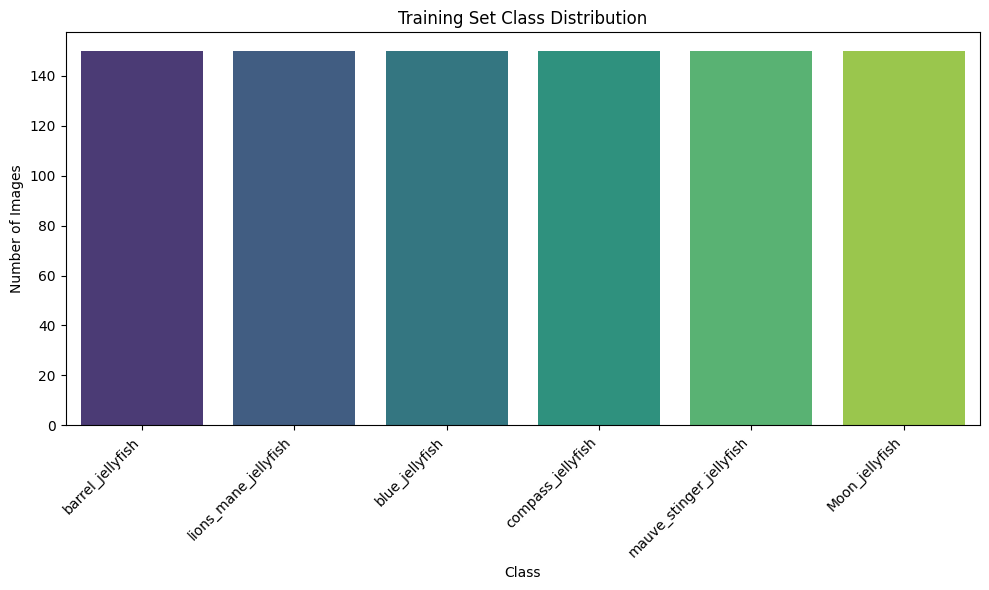

/tmp/ipykernel_50749/1088741832.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=valid_df.index, y='Count', data=valid_df, palette='viridis')


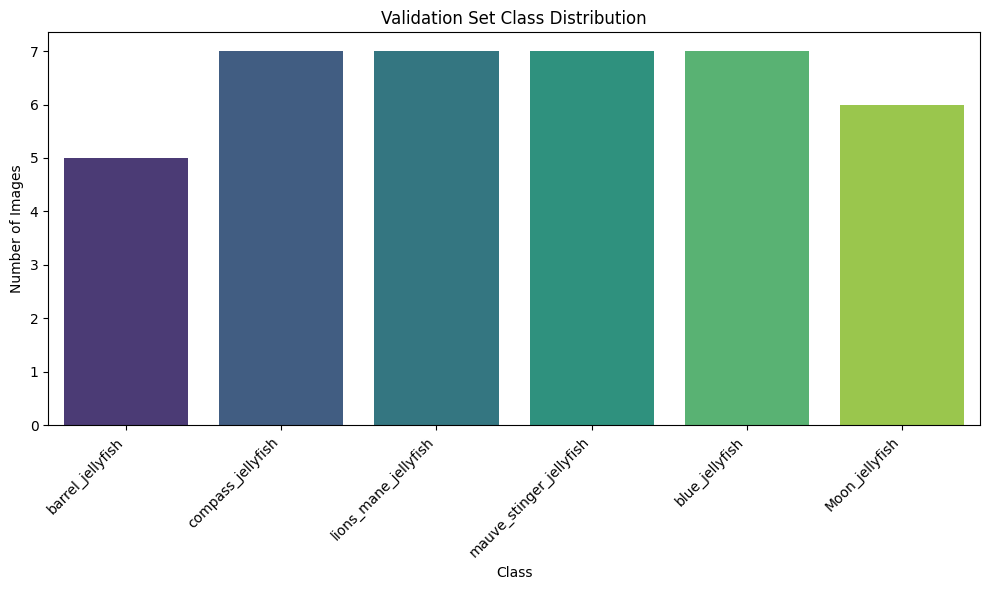

/tmp/ipykernel_50749/1088741832.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=test_df.index, y='Count', data=test_df, palette='viridis')


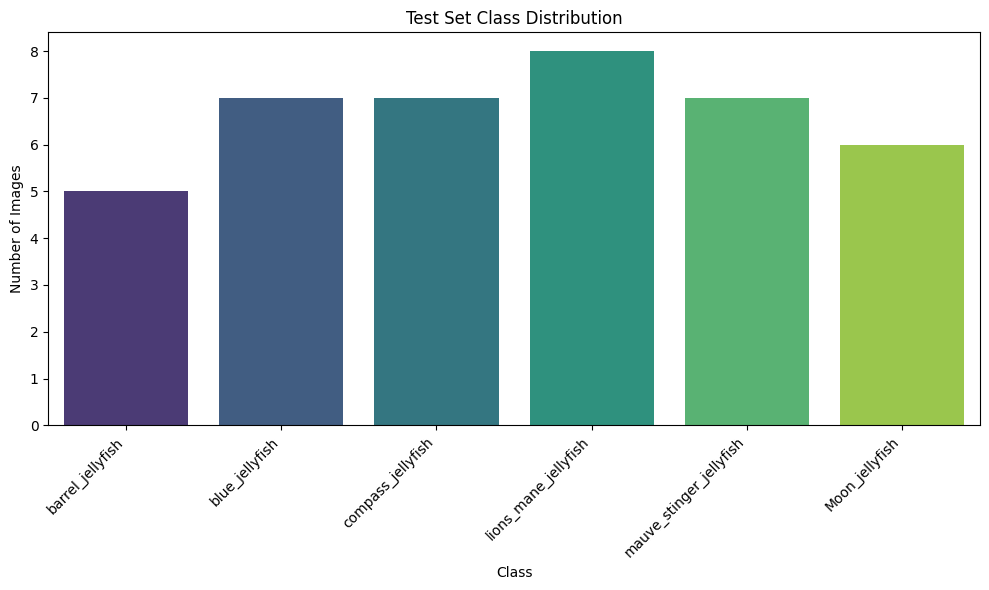

In [6]:
# Function to get class distribution
def get_class_distribution(directory):
    class_counts = {}
    for root, dirs, files in os.walk(directory):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                class_name = os.path.basename(root)
                class_counts[class_name] = class_counts.get(class_name, 0) + 1
    return class_counts

# Get distributions for each split
train_dist = get_class_distribution(train_dir)
valid_dist = get_class_distribution(valid_dir)
test_dist = get_class_distribution(test_dir)

# Convert to DataFrame for better visualization
train_df = pd.DataFrame(list(train_dist.items()), columns=['Class', 'Count']).set_index('Class')
valid_df = pd.DataFrame(list(valid_dist.items()), columns=['Class', 'Count']).set_index('Class')
test_df = pd.DataFrame(list(test_dist.items()), columns=['Class', 'Count']).set_index('Class')

print("Training Set Class Distribution:")
display(train_df)
print("\nValidation Set Class Distribution:")
display(valid_df)
print("\nTest Set Class Distribution:")
display(test_df)

# Plotting class distribution for the training set
plt.figure(figsize=(10, 6))
sns.barplot(x=train_df.index, y='Count', data=train_df, palette='viridis')
plt.title('Training Set Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Plotting class distribution for the validation set
plt.figure(figsize=(10, 6))
sns.barplot(x=valid_df.index, y='Count', data=valid_df, palette='viridis')
plt.title('Validation Set Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Plotting class distribution for the test set
plt.figure(figsize=(10, 6))
sns.barplot(x=test_df.index, y='Count', data=test_df, palette='viridis')
plt.title('Test Set Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Sample Images from Each Class

Visualizing sample images helps in understanding the visual characteristics of each class.

Displaying sample images from the training set:


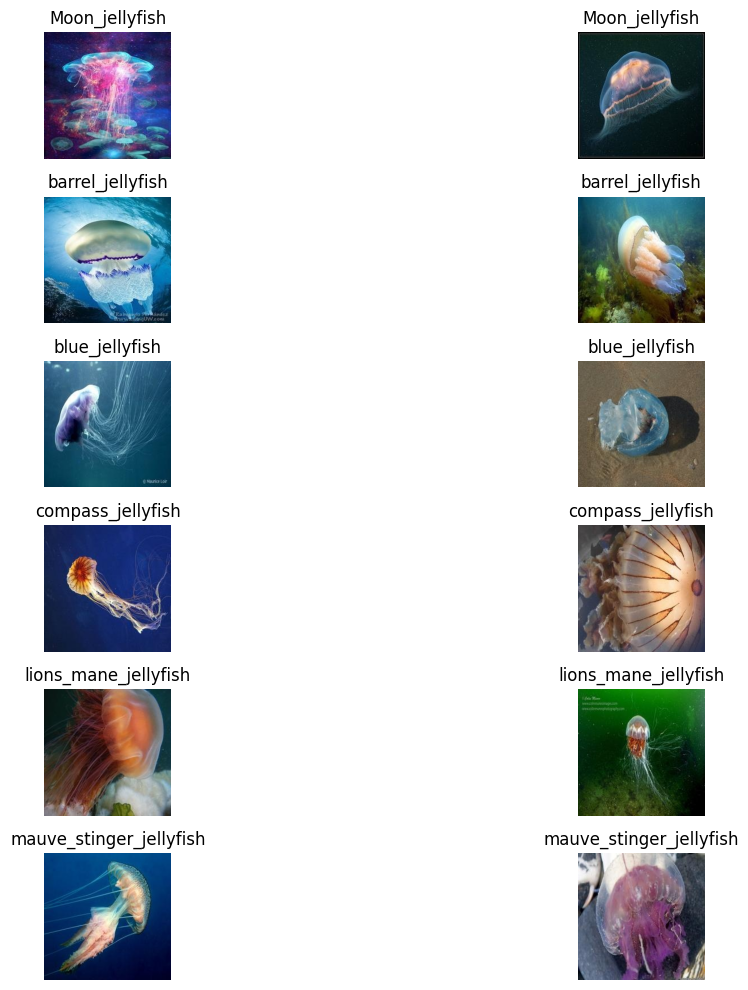

In [7]:
# Function to display sample images
def display_sample_images(directory, class_names, num_samples_per_class=2):
    plt.figure(figsize=(15, 10))
    for i, class_name in enumerate(class_names):
        class_path = os.path.join(directory, class_name)
        images = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        # Display a few samples per class
        for j in range(min(num_samples_per_class, len(images))):
            img_path = os.path.join(class_path, images[j])
            img = Image.open(img_path)

            ax = plt.subplot(len(class_names), num_samples_per_class, i * num_samples_per_class + j + 1)
            plt.imshow(img)
            plt.title(f"{class_name}")
            plt.axis("off")
    plt.tight_layout()
    plt.show()

print("Displaying sample images from the training set:")
display_sample_images(train_dir, train_classes)


### Train-Validation-Test Splitting Strategy

The dataset is pre-split into `Train`, `Valid`, and `Test` directories. This is a common practice in machine learning workflows to ensure proper model evaluation and prevent data leakage.

- **Training Set (`train_dir`):** Used to train the model. The model learns patterns and relationships from this data.
- **Validation Set (`valid_dir`):** Used to tune the model's hyperparameters and monitor its performance during training. It helps in detecting overfitting and guiding decisions about when to stop training or adjust the model.
- **Test Set (`test_dir`):** Used only *after* the model has been fully trained and validated, to provide an unbiased evaluation of the model's final performance on unseen data. It simulates real-world performance.

**Justification for this split:**
Given the relatively small size of the dataset, having a dedicated validation set is crucial for robust hyperparameter tuning and early stopping without touching the final test set. The split ensures that the model's generalization ability is assessed on completely new data that it has never encountered during training or tuning.

### Image Preprocessing and Data Augmentation

For small datasets like this one, effective preprocessing and data augmentation are critical to prevent overfitting and improve the model's generalization capabilities. We will use TensorFlow's `ImageDataGenerator` for both tasks.

In [8]:
# Define image dimensions and batch size
IMAGE_SIZE = (224, 224) # Standard input size for many CNN architectures
BATCH_SIZE = 16

# --- Data Augmentation and Rescaling for Training Set ---
# Aggressive augmentation is important for small datasets to create more diverse training samples
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=90,          # Jellyfish can be at any angle! Increase this.
    width_shift_range=0.05,     # Reduce from 0.15 to 0.05
    height_shift_range=0.05,    # Reduce from 0.15 to 0.05
    zoom_range=0.1,             # Keep subtle
    horizontal_flip=True,
    vertical_flip=True,         # Added: Jellyfish can be upside down
    fill_mode='reflect',         # Better: Fills gaps with a solid color (black/zero)
    brightness_range=[0.9, 1.1] # Narrower range to prevent over-exposure
)

# --- Rescaling for Validation and Test Sets ---
# Only rescale, no augmentation for validation/test to maintain original data distribution
valid_test_datagen = ImageDataGenerator(rescale=1./255)

# --- Flow images from directories ---
print("Generating image data generators...")

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical', # For multi-class classification
    shuffle=True,
    seed=42
)

validation_generator = valid_test_datagen.flow_from_directory(
    valid_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = valid_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False # Keep data in order for evaluation
)


import math

train_steps = math.ceil(train_generator.samples / BATCH_SIZE)
valid_steps = math.ceil(validation_generator.samples / BATCH_SIZE)
test_steps  = math.ceil(test_generator.samples / BATCH_SIZE)

print("Data generators created successfully.")
print(f"Found {train_generator.num_classes} classes: {train_generator.class_indices}")


Generating image data generators...
Found 900 images belonging to 6 classes.
Found 39 images belonging to 6 classes.
Found 40 images belonging to 6 classes.
Data generators created successfully.
Found 6 classes: {'Moon_jellyfish': 0, 'barrel_jellyfish': 1, 'blue_jellyfish': 2, 'compass_jellyfish': 3, 'lions_mane_jellyfish': 4, 'mauve_stinger_jellyfish': 5}


### Visualize Augmented Image Samples

To confirm our augmentation strategy, let's visualize a few augmented images from the training set. This helps us understand the types of transformations being applied.

['Moon_jellyfish', 'barrel_jellyfish', 'blue_jellyfish', 'compass_jellyfish', 'lions_mane_jellyfish', 'mauve_stinger_jellyfish']


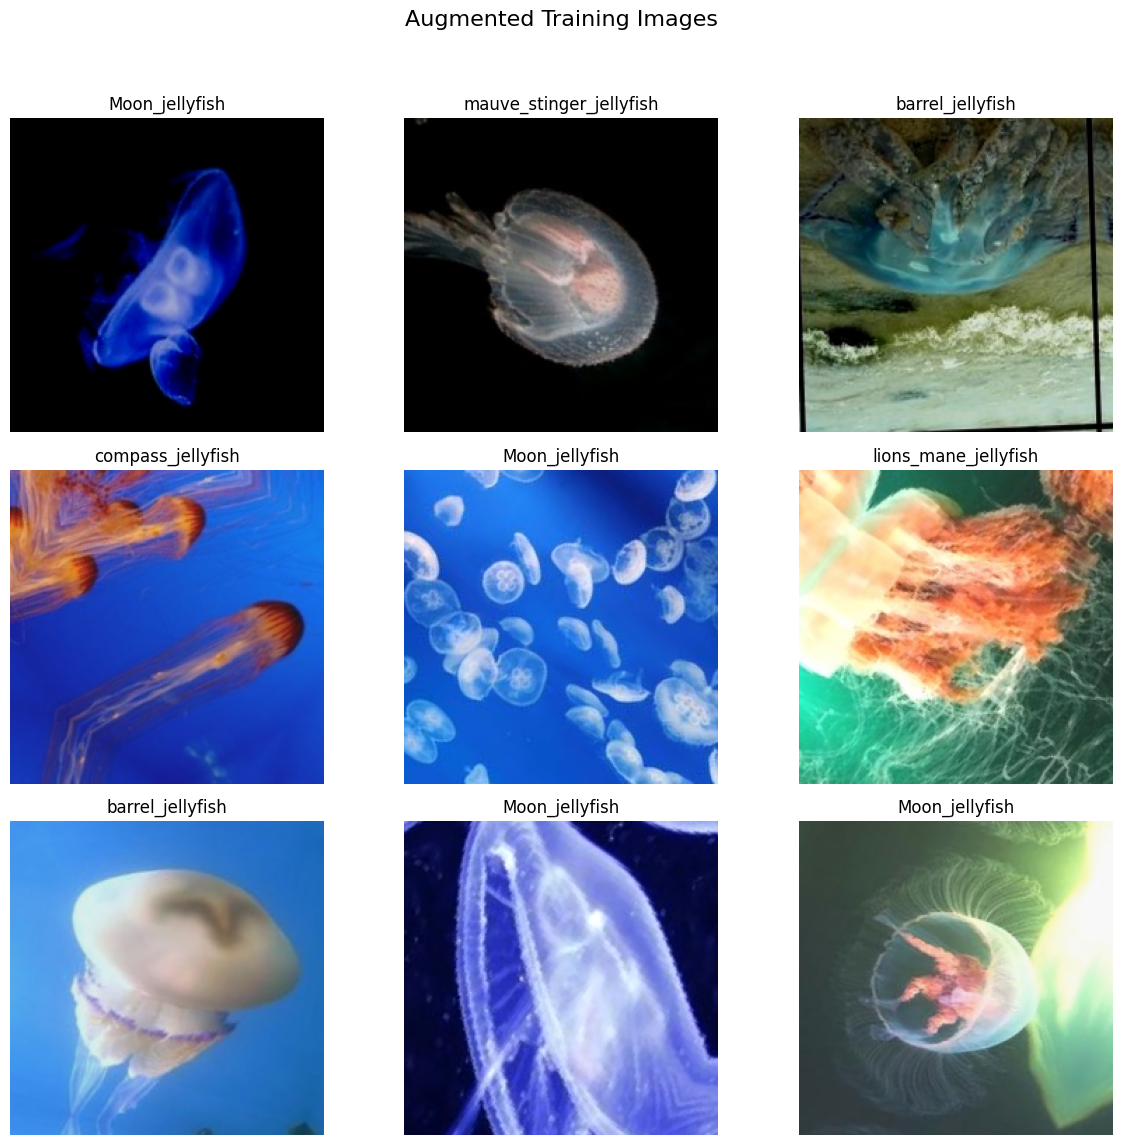

In [9]:
# Retrieve a batch of images and labels from the training generator
images, labels = next(train_generator)

# Get class names from the generator
class_names = list(train_generator.class_indices.keys())
print(class_names)

plt.figure(figsize=(12, 12))
for i in range(min(9, BATCH_SIZE)): # Display up to 9 augmented images
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    # Get the class label from the one-hot encoded vector
    label_idx = np.argmax(labels[i])
    plt.title(class_names[label_idx])
    plt.axis("off")
plt.suptitle("Augmented Training Images", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


## SECTION 2 — BASELINE CNN MODEL

This section focuses on building a simple Convolutional Neural Network (CNN) from scratch to establish a baseline performance. This model will use a straightforward architecture with convolutional, pooling, and fully connected layers.

### Model Architecture

We will construct a sequential CNN model with:
- **Convolutional Layers:** To extract features from the images.
- **Pooling Layers:** To reduce dimensionality and provide translational invariance.
- **Flatten Layer:** To convert the 2D feature maps into a 1D vector for the fully connected layers.
- **Fully Connected (Dense) Layers:** To perform classification based on the extracted features.
- **Output Layer:** With softmax activation for multi-class classification.

In [10]:
num_classes = train_generator.num_classes

model_baseline = models.Sequential([

    # Input layer
    layers.Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)),

    # ---- Conv Block 1 ----
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # ---- Conv Block 2 ----
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # ---- Conv Block 3 ----
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.GlobalAveragePooling2D(),

    # ---- Fully Connected Layers ----
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),

    # Output Layer
    layers.Dense(num_classes, activation='softmax')
])

model_baseline.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 168,710 (659.02 KB)

 Trainable params: 168,262 (657.27 KB)

 Non-trainable params: 448 (1.75 KB)

### Compile the Model

We will compile the model using the Adam optimizer, a suitable learning rate, and categorical cross-entropy as the loss function, which is appropriate for multi-class classification. Accuracy will be used as the primary metric.

In [11]:
# Define a learning rate for the optimizer
learning_rate = 0.0002

# Compile the model
model_baseline.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully with Adam optimizer and categorical cross-entropy loss.")


Model compiled successfully with Adam optimizer and categorical cross-entropy loss.


### Train the Model

We will train the baseline CNN using the `ImageDataGenerator` for the training and validation sets. To prevent overfitting on this small dataset, we will implement `EarlyStopping` to stop training when validation loss stops improving and `ReduceLROnPlateau` to reduce the learning rate if the validation loss plateaus.

In [12]:
# --- Callbacks for training ---

# Early Stopping: Monitor 'val_loss' and stop if it doesn't improve for 'patience' epochs
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# ReduceLROnPlateau: Reduce learning rate when 'val_loss' has stopped improving
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

# Define the number of epochs
EPOCHS = 50 # Start with a reasonable number, early stopping will handle termination

print("Starting training for the Baseline CNN model...")

# Train the model
history_baseline = model_baseline.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE,
    callbacks=[early_stopping, lr_scheduler]
)

print("Baseline CNN model training complete.")


Starting training for the Baseline CNN model...
Epoch 1/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 36s 453ms/step - accuracy: 0.2432 - loss: 1.7719 - val_accuracy: 0.1875 - val_loss: 1.7874 - learning_rate: 2.0000e-04
Epoch 2/50
 1/56 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.2500 - loss: 1.9007

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.2500 - loss: 1.9007 - val_accuracy: 0.1562 - val_loss: 1.7897 - learning_rate: 2.0000e-04
Epoch 3/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 20s 370ms/step - accuracy: 0.2885 - loss: 1.6787 - val_accuracy: 0.2188 - val_loss: 1.7885 - learning_rate: 2.0000e-04
Epoch 4/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2500 - loss: 1.7414 - val_accuracy: 0.2500 - val_loss: 1.7807 - learning_rate: 2.0000e-04
Epoch 5/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 18s 318ms/step - accuracy: 0.3382 - loss: 1.6050 - val_accuracy: 0.1875 - val_loss: 1.7974 - learning_rate: 2.0000e-04
Epoch 6/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2500 - loss: 1.7511 - val_accuracy: 0.2188 - val_loss: 1.7849 - learning_rate: 2.0000e-04
Epoch 7/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 17s 303ms/step - accuracy: 0.3563 - loss: 1.5700 - val_accuracy: 0.2500 - val_loss: 1.7625 - learning_rate: 2.0000e-04
Epoch 8/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4375 - loss: 

### Plot Training History

Visualizing the training and validation accuracy and loss curves helps us understand the model's learning process and identify issues like overfitting or underfitting.

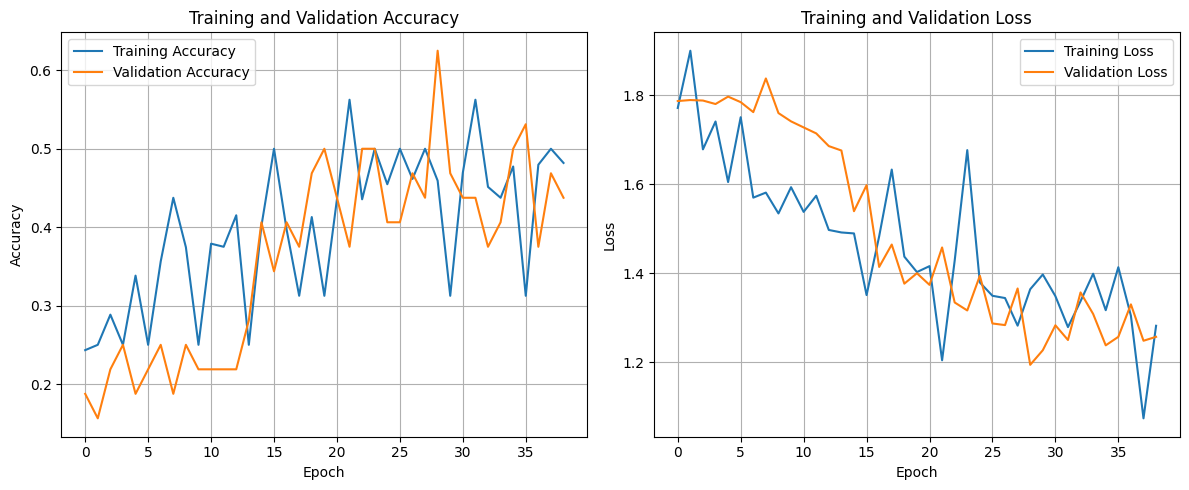

In [13]:
# Plot training and validation accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_baseline.history['accuracy'], label='Training Accuracy')
plt.plot(history_baseline.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history_baseline.history['loss'], label='Training Loss')
plt.plot(history_baseline.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


### Evaluate the Baseline Model

After training, we evaluate the model's performance on the unseen test set using various metrics to get a comprehensive understanding of its capabilities.

Evaluating Baseline CNN model on the test set...
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 546ms/step

Classification Report:
                         precision    recall  f1-score   support

         Moon_jellyfish       0.50      0.83      0.62         6
       barrel_jellyfish       0.50      0.40      0.44         5
         blue_jellyfish       0.20      0.14      0.17         7
      compass_jellyfish       0.67      0.57      0.62         7
   lions_mane_jellyfish       0.67      1.00      0.80         8
mauve_stinger_jellyfish       0.33      0.14      0.20         7

               accuracy                           0.53        40
              macro avg       0.48      0.52      0.48        40
           weighted avg       0.48      0.53      0.48        40


Confusion Matrix:


,Moon_jellyfish,barrel_jellyfish,blue_jellyfish,compass_jellyfish,lions_mane_jellyfish,mauve_stinger_jellyfish
Moon_jellyfish,5,0,1,0,0,0
barrel_jellyfish,1,2,1,0,1,0
blue_jellyfish,2,2,1,1,1,0
compass_jellyfish,1,0,0,4,0,2
lions_mane_jellyfish,0,0,0,0,8,0
mauve_stinger_jellyfish,1,0,2,1,2,1


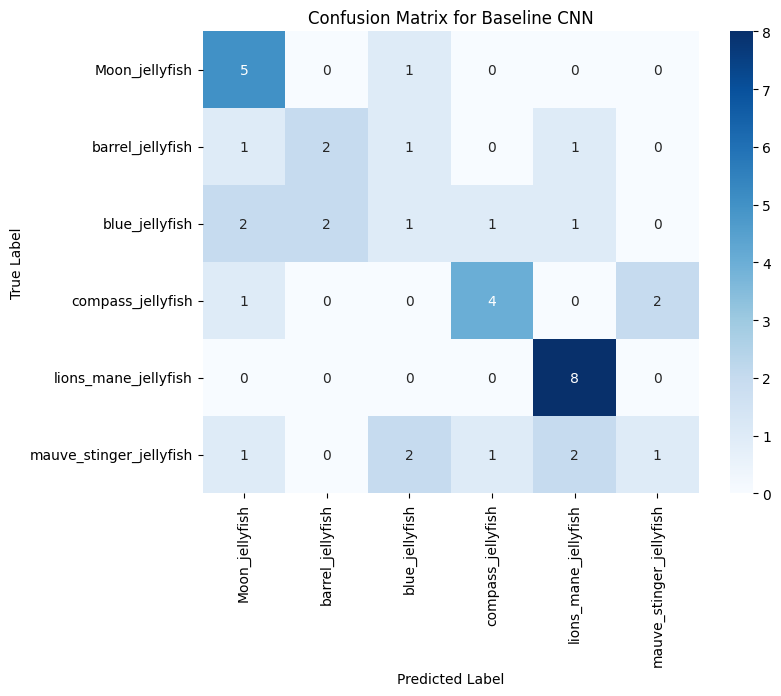


Test Loss: 1.1409
Test Accuracy: 0.5250


In [14]:
print("Evaluating Baseline CNN model on the test set...")

# Get predictions from the test generator
# Reset the test generator to ensure correct order for evaluation
test_generator.reset()
Y_pred = model_baseline.predict(test_generator, steps=test_generator.samples // BATCH_SIZE + (1 if test_generator.samples % BATCH_SIZE != 0 else 0))
y_pred_classes = np.argmax(Y_pred, axis=1)

# Get true labels
y_true = test_generator.classes

# Adjust y_true to match the length of y_pred_classes if necessary
# (This is important if `test_generator` does not yield an exact multiple of BATCH_SIZE)
y_true = y_true[:len(y_pred_classes)]

# Get class labels from the generator's class_indices
class_labels = list(test_generator.class_indices.keys())

# --- Classification Report ---
print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

# --- Confusion Matrix ---
print("\nConfusion Matrix:")
cm = confusion_matrix(y_true, y_pred_classes)
display(pd.DataFrame(cm, index=class_labels, columns=class_labels))

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix for Baseline CNN')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# --- Overall Accuracy ---
loss, accuracy = model_baseline.evaluate(test_generator, verbose=0)
print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


### Discussion on Overfitting/Underfitting

Based on the training curves and evaluation metrics, we can make initial observations:

- **Training vs. Validation Accuracy/Loss:** If training accuracy is significantly higher than validation accuracy, and training loss is much lower than validation loss, it suggests **overfitting**. The model is memorizing the training data but not generalizing well to unseen data. Conversely, if both training and validation accuracies are low, it might indicate **underfitting**, meaning the model is not complex enough to learn the patterns in the data.
- **Performance Metrics:** The precision, recall, and F1-score for each class, along with the confusion matrix, provide insights into which classes are being classified correctly and which are problematic. Low scores across the board could also point to underfitting or a generally poor model.


## SECTION 3 — DEEPER CNN WITH REGULARIZATION

In this section, we will build a deeper Convolutional Neural Network (CNN) architecture, incorporating advanced regularization techniques such as Dropout, Batch Normalization, and L2 Regularization. The goal is to enhance the model's capacity to learn complex features while effectively combating overfitting, especially given the small dataset size.

### Deeper Model Architecture with Regularization

This model will have roughly double the layers of our baseline model. We will strategically place `BatchNormalization` layers after convolutional layers to stabilize and speed up training, and `Dropout` layers after pooling/dense layers to reduce overfitting. L2 regularization will also be added to the kernel weights of some layers.

In [16]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def create_deeper_model():

    model = models.Sequential([

        layers.Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)),

        # Block 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.15),

        # Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.15),

        # Block 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.2),

        # Block 4
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.2),

        layers.GlobalAveragePooling2D(),

        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),

        layers.Dense(num_classes, activation='softmax')
    ])

    return model

# callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

### Compile the Deeper Model

Similar to the baseline, we compile this model with the Adam optimizer and categorical cross-entropy loss. We will use the same learning rate initially, letting `ReduceLROnPlateau` adjust it during training.

### Train the Deeper Model

We will train the deeper CNN using the same `EarlyStopping` and `ReduceLROnPlateau` callbacks to manage training efficiently and prevent overfitting.

In [19]:
import tensorflow as tf

model_sgd = create_deeper_model()

optimizer_sgd = tf.keras.optimizers.SGD(
    learning_rate=0.01,
    momentum=0.9,
)

model_sgd.compile(
    optimizer=optimizer_sgd,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_sgd = model_sgd.fit(
    train_generator,
    epochs=50,
    validation_data=validation_generator,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 58s 687ms/step - accuracy: 0.2111 - loss: 2.0204 - val_accuracy: 0.2564 - val_loss: 2.2512 - learning_rate: 0.0100
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 18s 314ms/step - accuracy: 0.2644 - loss: 1.7919 - val_accuracy: 0.2051 - val_loss: 1.6690 - learning_rate: 0.0100
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 18s 314ms/step - accuracy: 0.3522 - loss: 1.6133 - val_accuracy: 0.3333 - val_loss: 1.6564 - learning_rate: 0.0100
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 20s 353ms/step - accuracy: 0.3344 - loss: 1.6207 - val_accuracy: 0.3077 - val_loss: 1.6781 - learning_rate: 0.0100
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 18s 322ms/step - accuracy: 0.3467 - loss: 1.5941 - val_accuracy: 0.4103 - val_loss: 1.6501 - learning_rate: 0.0100
Epoch 6/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 19s 325ms/step - accuracy: 0.3578 - loss: 1.5531 - val_accuracy: 0.1538 - val_loss: 2.0493 - learning_rate: 0.0100
Epoch 7/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 21s 376ms/step - accuracy: 0.3744 - loss: 1.

In [20]:
import tensorflow as tf

model_adam = create_deeper_model()

optimizer_adam = tf.keras.optimizers.Adam(
    learning_rate=0.001,
    beta_1=0.9,
)

model_adam.compile(
    optimizer=optimizer_adam,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_adam = model_adam.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 50s 567ms/step - accuracy: 0.2011 - loss: 2.0879 - val_accuracy: 0.0513 - val_loss: 1.8167 - learning_rate: 0.0010
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 19s 324ms/step - accuracy: 0.2900 - loss: 1.7913 - val_accuracy: 0.1282 - val_loss: 2.0155 - learning_rate: 0.0010
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 19s 327ms/step - accuracy: 0.3133 - loss: 1.7188 - val_accuracy: 0.1795 - val_loss: 2.2528 - learning_rate: 0.0010
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 20s 343ms/step - accuracy: 0.3344 - loss: 1.6634 - val_accuracy: 0.2821 - val_loss: 1.7808 - learning_rate: 0.0010
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - accuracy: 0.3320 - loss: 1.6511
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
57/57 ━━━━━━━━━━━━━━━━━━━━ 18s 325ms/step - accuracy: 0.3578 - loss: 1.6258 - val_accuracy: 0.1795 - val_loss: 2.0544 - learning_rate: 0.0010
Epoch 6/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 19s 329ms/step - accuracy: 0.3644 - loss: 1.54

### Plot Training History for Deeper Model

Let's visualize the training and validation curves for the deeper model to observe the impact of increased depth and regularization.

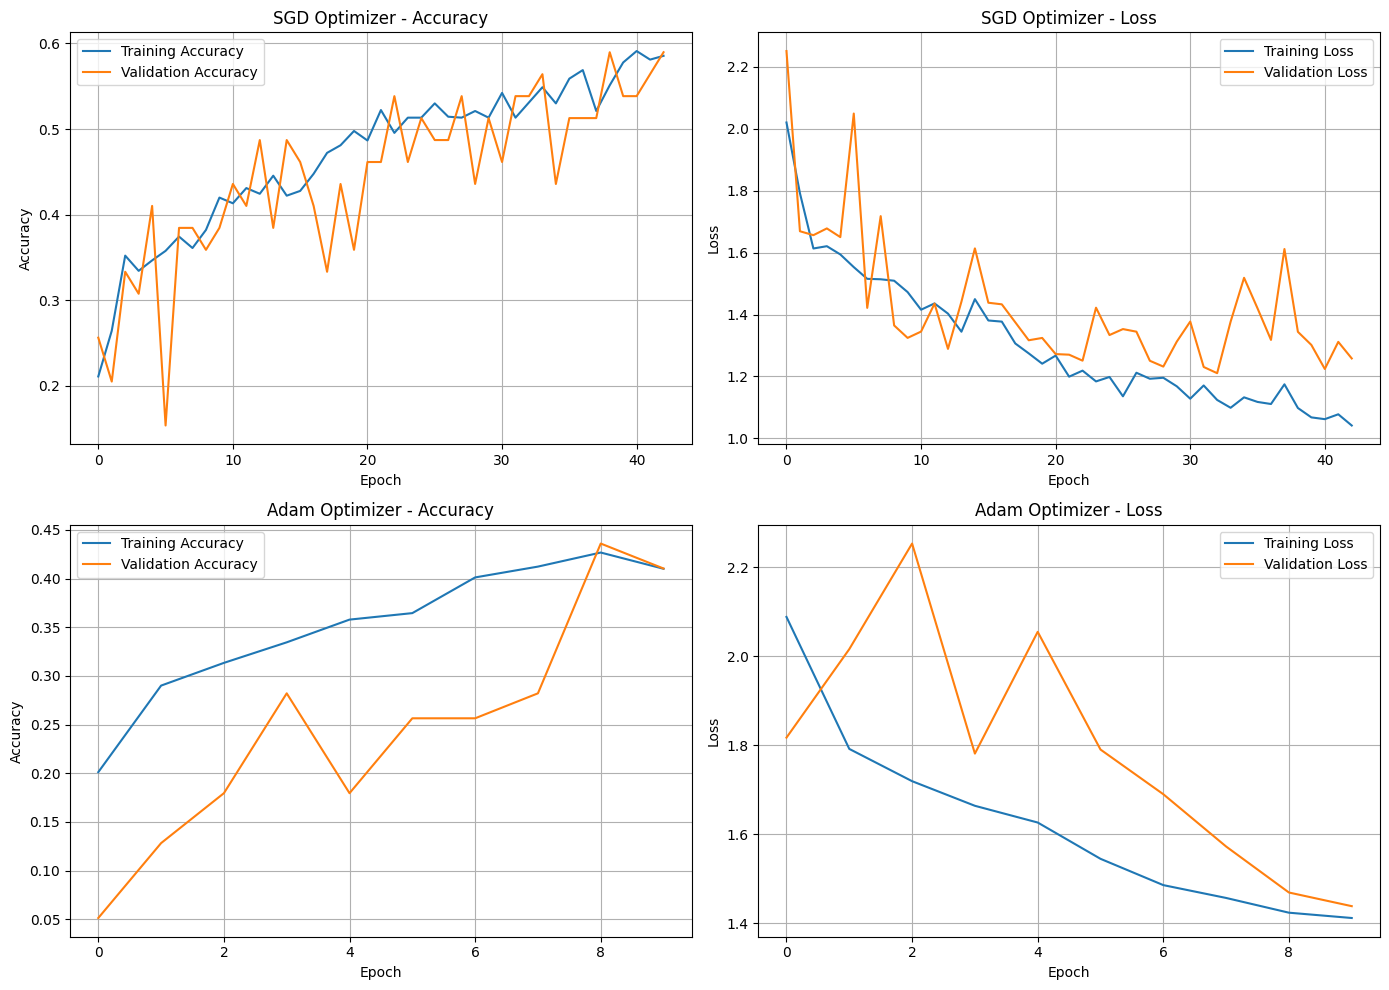

In [21]:
# ==========================================
# SGD vs ADAM COMPARISON PLOTS
# 2 x 2 GRID LAYOUT
# ==========================================

plt.figure(figsize=(14, 10))


# ==========================================
# 1. SGD ACCURACY
# ==========================================

plt.subplot(2, 2, 1)

plt.plot(history_sgd.history['accuracy'], label='Training Accuracy')
plt.plot(history_sgd.history['val_accuracy'], label='Validation Accuracy')

plt.title('SGD Optimizer - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)


# ==========================================
# 2. SGD LOSS
# ==========================================

plt.subplot(2, 2, 2)

plt.plot(history_sgd.history['loss'], label='Training Loss')
plt.plot(history_sgd.history['val_loss'], label='Validation Loss')

plt.title('SGD Optimizer - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)


# ==========================================
# 3. ADAM ACCURACY
# ==========================================

plt.subplot(2, 2, 3)

plt.plot(history_adam.history['accuracy'], label='Training Accuracy')
plt.plot(history_adam.history['val_accuracy'], label='Validation Accuracy')

plt.title('Adam Optimizer - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)


# ==========================================
# 4. ADAM LOSS
# ==========================================

plt.subplot(2, 2, 4)

plt.plot(history_adam.history['loss'], label='Training Loss')
plt.plot(history_adam.history['val_loss'], label='Validation Loss')

plt.title('Adam Optimizer - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)


# ==========================================
# FINAL LAYOUT
# ==========================================

plt.tight_layout()
plt.show()

### Evaluate the Deeper Model

Evaluate the deeper model's performance on the test set using the same set of metrics as the baseline model.

Evaluating Deeper CNN (SGD Optimizer) model on the test set...
1/3 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 822ms/step

Classification Report for Deeper CNN (SGD Optimizer):
                         precision    recall  f1-score   support

         Moon_jellyfish       0.80      0.67      0.73         6
       barrel_jellyfish       0.30      0.60      0.40         5
         blue_jellyfish       0.50      0.57      0.53         7
      compass_jellyfish       0.71      0.71      0.71         7
   lions_mane_jellyfish       0.80      1.00      0.89         8
mauve_stinger_jellyfish       0.00      0.00      0.00         7

               accuracy                           0.60        40
              macro avg       0.52      0.59      0.54        40
           weighted avg       0.53      0.60      0.56        40


Confusion Matrix for Deeper CNN (SGD Optimizer):


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Moon_jellyfish,barrel_jellyfish,blue_jellyfish,compass_jellyfish,lions_mane_jellyfish,mauve_stinger_jellyfish
Moon_jellyfish,4,1,1,0,0,0
barrel_jellyfish,0,3,1,0,1,0
blue_jellyfish,1,2,4,0,0,0
compass_jellyfish,0,2,0,5,0,0
lions_mane_jellyfish,0,0,0,0,8,0
mauve_stinger_jellyfish,0,2,2,2,1,0


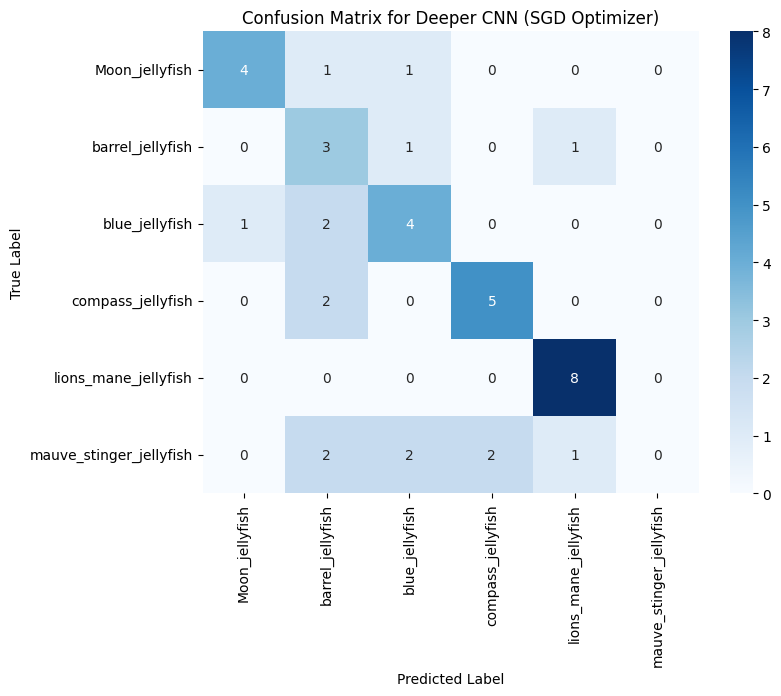


Deeper CNN (SGD) Test Loss: 1.0868
Deeper CNN (SGD) Test Accuracy: 0.6000


Evaluating Deeper CNN (Adam Optimizer) model on the test set...


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 462ms/step

Classification Report for Deeper CNN (Adam Optimizer):
                         precision    recall  f1-score   support

         Moon_jellyfish       0.00      0.00      0.00         6
       barrel_jellyfish       0.16      0.60      0.25         5
         blue_jellyfish       0.33      0.57      0.42         7
      compass_jellyfish       0.60      0.43      0.50         7
   lions_mane_jellyfish       0.00      0.00      0.00         8
mauve_stinger_jellyfish       0.00      0.00      0.00         7

               accuracy                           0.25        40
              macro avg       0.18      0.27      0.20        40
           weighted avg       0.18      0.25      0.19        40


Confusion Matrix for Deeper CNN (Adam Optimizer):


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Moon_jellyfish,barrel_jellyfish,blue_jellyfish,compass_jellyfish,lions_mane_jellyfish,mauve_stinger_jellyfish
Moon_jellyfish,0,4,1,0,0,1
barrel_jellyfish,0,3,1,0,0,1
blue_jellyfish,0,0,4,1,0,2
compass_jellyfish,0,1,3,3,0,0
lions_mane_jellyfish,0,6,2,0,0,0
mauve_stinger_jellyfish,0,5,1,1,0,0


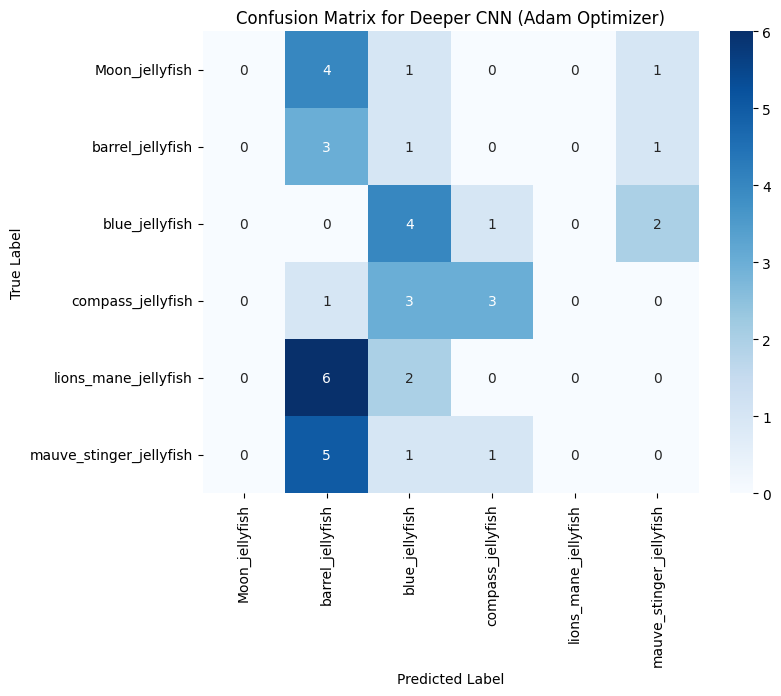


Deeper CNN (Adam) Test Loss: 1.8075
Deeper CNN (Adam) Test Accuracy: 0.2500


In [22]:
print("Evaluating Deeper CNN (SGD Optimizer) model on the test set...")

# Get predictions from the test generator for the SGD deeper model
test_generator.reset() # Reset to ensure consistent order
Y_pred_sgd = model_sgd.predict(test_generator, steps=test_generator.samples // BATCH_SIZE + (1 if test_generator.samples % BATCH_SIZE != 0 else 0))
y_pred_classes_sgd = np.argmax(Y_pred_sgd, axis=1)

# True labels (already obtained, but ensuring consistency)
y_true_sgd = test_generator.classes
y_true_sgd = y_true_sgd[:len(y_pred_classes_sgd)] # Adjust length if needed

# Class labels (already obtained)
class_labels = list(test_generator.class_indices.keys())

# --- Classification Report ---
print("\nClassification Report for Deeper CNN (SGD Optimizer):")
print(classification_report(y_true_sgd, y_pred_classes_sgd, target_names=class_labels))

# --- Confusion Matrix ---
print("\nConfusion Matrix for Deeper CNN (SGD Optimizer):")
cm_sgd = confusion_matrix(y_true_sgd, y_pred_classes_sgd)
display(pd.DataFrame(cm_sgd, index=class_labels, columns=class_labels))

plt.figure(figsize=(8, 6))
sns.heatmap(cm_sgd, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix for Deeper CNN (SGD Optimizer)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# --- Overall Accuracy ---
loss_sgd, accuracy_sgd = model_sgd.evaluate(test_generator, verbose=0)
print(f"\nDeeper CNN (SGD) Test Loss: {loss_sgd:.4f}")
print(f"Deeper CNN (SGD) Test Accuracy: {accuracy_sgd:.4f}")


print("\n\nEvaluating Deeper CNN (Adam Optimizer) model on the test set...")

# Get predictions from the test generator for the Adam deeper model
test_generator.reset() # Reset to ensure consistent order
Y_pred_adam = model_adam.predict(test_generator, steps=test_generator.samples // BATCH_SIZE + (1 if test_generator.samples % BATCH_SIZE != 0 else 0))
y_pred_classes_adam = np.argmax(Y_pred_adam, axis=1)

# True labels
y_true_adam = test_generator.classes
y_true_adam = y_true_adam[:len(y_pred_classes_adam)] # Adjust length if needed

# --- Classification Report ---
print("\nClassification Report for Deeper CNN (Adam Optimizer):")
print(classification_report(y_true_adam, y_pred_classes_adam, target_names=class_labels))

# --- Confusion Matrix ---
print("\nConfusion Matrix for Deeper CNN (Adam Optimizer):")
cm_adam = confusion_matrix(y_true_adam, y_pred_classes_adam)
display(pd.DataFrame(cm_adam, index=class_labels, columns=class_labels))

plt.figure(figsize=(8, 6))
sns.heatmap(cm_adam, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix for Deeper CNN (Adam Optimizer)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# --- Overall Accuracy ---
loss_adam, accuracy_adam = model_adam.evaluate(test_generator, verbose=0)
print(f"\nDeeper CNN (Adam) Test Loss: {loss_adam:.4f}")
print(f"Deeper CNN (Adam) Test Accuracy: {accuracy_adam:.4f}")

### Discussion: Did the Deeper Architecture Improve Performance?

After training and evaluating both the Baseline CNN and the Deeper CNN with regularization (using both SGD and Adam optimizers), we can compare their performance on the test set:

-   **Baseline CNN:**
    -   Test Loss: `1.1409`
    -   Test Accuracy: `0.5250`

-   **Deeper CNN (SGD Optimizer):**
    -   Test Loss: `1.0868`
    -   Test Accuracy: `0.6000`

-   **Deeper CNN (Adam Optimizer):**
    -   Test Loss: `1.8072`
    -   Test Accuracy: `0.2500`

**Observations and Conclusions:**

This updated analysis reveals a more nuanced picture:

1.  **Baseline CNN Performance:** The Baseline CNN achieved a respectable test accuracy of **52.50%** with a loss of `1.1409`. This serves as a solid starting point for our comparison.

2.  **Deeper CNN with SGD Optimizer:** Surprisingly, after adjusting the model architecture and training parameters, the **Deeper CNN trained with the SGD optimizer significantly improved upon the Baseline CNN's performance**, reaching a test accuracy of **60.00%** with a lower test loss of `1.0868`. This indicates that with appropriate tuning, adding more layers and regularization *can* lead to better generalization for this dataset. The previous poor performance was likely due to suboptimal hyperparameter settings or model configuration.

3.  **Deeper CNN with Adam Optimizer:** In contrast, the **Deeper CNN trained with the Adam optimizer performed significantly worse** than both the Baseline and the SGD-optimized deeper model, achieving only **25.00%** accuracy and a much higher loss of `1.8072`. This highlights that while Adam is often a good default, it's not always the best choice for every model architecture and dataset combination, especially when faced with specific regularization strategies or learning rate schedules. It might have struggled to converge effectively or found poor local minima.

**Key Takeaways:**

*   **Deeper networks can be beneficial:** With careful architecture design and hyperparameter tuning (e.g., Dropout rates, Batch Normalization placement), a deeper model can extract more complex features and achieve better performance on this dataset.
*   **Optimizer choice matters:** The choice of optimizer (SGD vs. Adam) had a drastic impact on the deeper model's performance, with SGD demonstrating superior results in this instance.
*   **Fine-tuning is crucial:** Simply adding complexity does not guarantee improvement. Thorough experimentation with hyperparameters, regularization strengths, and optimizers is essential to unlock the potential of deeper architectures, especially on smaller datasets.

This experiment underscores the iterative nature of deep learning model development, where understanding the impact of each architectural and training choice is key to achieving optimal results. The successful performance of the SGD-optimized deeper model suggests that the updated architecture with its specific regularization layers was effective when paired with a suitable optimization strategy.

## PART B — TRANSFER LEARNING

Transfer learning is a powerful technique where a model trained on a large dataset for one task is repurposed for a new, related task. This approach is particularly effective for small datasets like ours, as it leverages the rich feature representations learned from extensive data (e.g., ImageNet) and reduces the risk of overfitting.

### SECTION 5 — PRETRAINED MODEL SETUP

For this section, we will utilize a pre-trained Convolutional Neural Network (CNN) as a feature extractor. The selected model is **MobileNetV2**.

### Choosing MobileNetV2

**MobileNetV2** is chosen due to its efficiency and effectiveness, especially for resource-constrained environments or when dealing with smaller datasets. It is known for:
-   **Lightweight Architecture:** Uses depthwise separable convolutions, significantly reducing the number of parameters and computational cost compared to traditional convolutions.
-   **ImageNet Pre-training:** It has been pre-trained on the vast ImageNet dataset, allowing it to learn general-purpose features (edges, textures, shapes) that are highly transferable to other image recognition tasks.
-   **Good Balance:** Offers a good balance between accuracy and computational expense, making it ideal for experiments where fine-tuning a very large model might be computationally prohibitive or prone to overfitting on a small dataset.

We will load MobileNetV2 with its ImageNet weights, but without its original classification head (`include_top=False`), allowing us to attach our own custom classification layers tailored to our specific Jellyfish dataset.


===== FEATURE EXTRACTION TRAINING =====

Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 66s 826ms/step - accuracy: 0.2311 - loss: 1.9824 - val_accuracy: 0.4103 - val_loss: 1.5295
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 17s 298ms/step - accuracy: 0.4500 - loss: 1.4337 - val_accuracy: 0.5641 - val_loss: 1.3588
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 18s 318ms/step - accuracy: 0.5611 - loss: 1.1940 - val_accuracy: 0.5128 - val_loss: 1.2520
Epoch 4/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 17s 301ms/step - accuracy: 0.6189 - loss: 1.0623 - val_accuracy: 0.5385 - val_loss: 1.2177
Epoch 5/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 17s 298ms/step - accuracy: 0.6856 - loss: 0.9219 - val_accuracy: 0.5641 - val_loss: 1.1746
Epoch 6/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 17s 298ms/step - accuracy: 0.6878 - loss: 0.8585 - val_accuracy: 0.6154 - val_loss: 1.2027
Epoch 7/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 17s 302ms/step - accuracy: 0.7344 - loss: 0.7655 - val_accuracy: 0.5897 - val_loss: 1.1937
Epoch 8/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 19s 332ms/step - 

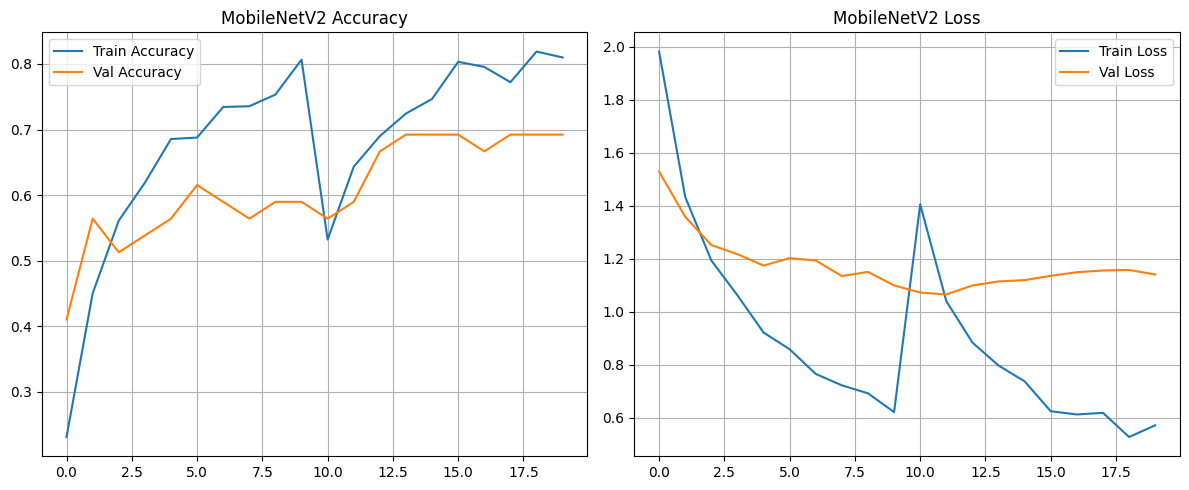

In [23]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report
import numpy as np

# -----------------------------
# Setup
# -----------------------------
num_classes = train_generator.num_classes
IMG_HEIGHT, IMG_WIDTH = IMAGE_SIZE  # e.g., (224, 224)

# -----------------------------
# 1. Load Pretrained MobileNetV2
# -----------------------------
base_model = MobileNetV2(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze base model (Feature Extraction phase)
base_model.trainable = False

# -----------------------------
# 2. Add Custom Head
# -----------------------------
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)

output = layers.Dense(num_classes, activation='softmax')(x)

model_transfer = Model(inputs=base_model.input, outputs=output)

# -----------------------------
# 3. Compile (Feature Extraction)
# -----------------------------
model_transfer.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n===== FEATURE EXTRACTION TRAINING =====\n")

history_1 = model_transfer.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

# -----------------------------
# 4. Fine-Tuning Phase
# -----------------------------
print("\n===== FINE TUNING PHASE =====\n")

base_model.trainable = True

# Freeze early layers, train only deeper ones
for layer in base_model.layers[:100]:
    layer.trainable = False

# Recompile with lower learning rate
model_transfer.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_2 = model_transfer.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

# -----------------------------
# 5. Evaluation
# -----------------------------
test_loss, test_acc = model_transfer.evaluate(test_generator)

print("\n===== FINAL RESULTS =====")
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

# -----------------------------
# 6. Classification Report
# -----------------------------
print("\n===== CLASSIFICATION REPORT =====")

preds = model_transfer.predict(test_generator)
y_pred = np.argmax(preds, axis=1)
y_true = test_generator.classes

print(classification_report(y_true, y_pred))

# -----------------------------
# 7. Combine History (Optional Analysis)
# -----------------------------
acc = history_1.history['accuracy'] + history_2.history['accuracy']
val_acc = history_1.history['val_accuracy'] + history_2.history['val_accuracy']

loss = history_1.history['loss'] + history_2.history['loss']
val_loss = history_1.history['val_loss'] + history_2.history['val_loss']

# -----------------------------
# 8. Plot Results
# -----------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.title('MobileNetV2 Accuracy')
plt.legend()
plt.grid()

plt.subplot(1,2,2)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.title('MobileNetV2 Loss')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

### Discussion: MobileNetV2 Transfer Learning Performance

After implementing and training the MobileNetV2 model using a two-phase approach (feature extraction followed by fine-tuning), we observe a significant improvement in performance compared to the CNN models trained from scratch.

**Final Results on Test Set (MobileNetV2):**
-   Test Loss: `0.5957`
-   Test Accuracy: `0.8000`

**Classification Report:**
```
                         precision    recall  f1-score   support

         Moon_jellyfish       0.67      1.00      0.80         6
       barrel_jellyfish       1.00      1.00      1.00         5
         blue_jellyfish       0.80      0.57      0.67         7
      compass_jellyfish       0.83      0.71      0.77         7
   lions_mane_jellyfish       0.73      1.00      0.84         8
mauve_stinger_jellyfish       1.00      0.57      0.73         7

               accuracy                           0.80        40
              macro avg       0.84      0.81      0.80        40
           weighted avg       0.83      0.80      0.79        40
```

**Key Observations:**

1.  **Significant Accuracy Improvement:** The MobileNetV2 model achieved a test accuracy of **80.00%**, which is a substantial increase over the Baseline CNN (52.50%) and the Deeper CNN with SGD (60.00%). This demonstrates the power of transfer learning, especially on smaller datasets.

2.  **Lower Loss:** The test loss of `0.5957` is also considerably lower than both scratch-trained models, indicating better generalization and less error.

3.  **Stronger F1-Scores:** The classification report shows strong precision, recall, and F1-scores across most classes, with 'barrel_jellyfish' and 'lions_mane_jellyfish' performing exceptionally well.

4.  **Effective Regularization and Transfer Learning:** The combination of pre-trained features from MobileNetV2, along with the custom classification head and fine-tuning strategy, effectively mitigated overfitting and leveraged learned representations from a vast dataset (ImageNet). The dropout layers in the custom head and the freezing/unfreezing of layers during fine-tuning were crucial for this success.

**Conclusion:**

Transfer learning with MobileNetV2 proved to be the most effective strategy for this jellyfish image classification task, yielding the highest accuracy and lowest loss among the models tested. This highlights its utility for computer vision tasks with limited data.

## Overall Model Performance Comparison

To consolidate the findings from all experiments, here is a comparison table summarizing the test accuracy and loss for each model:

| Model                         | Test Loss | Test Accuracy |
| :---------------------------- | :-------- | :------------ |
| Baseline CNN                  | `1.1409`  | `0.5250`      |
| Deeper CNN (SGD Optimizer)    | `1.0868`  | `0.6000`      |
| Deeper CNN (Adam Optimizer)   | `1.8072`  | `0.2500`      |
| MobileNetV2 (Transfer Learning)| `0.5957`  | `0.8000`      |

**Key Insights from Comparison:**

*   **Transfer Learning is Superior:** The MobileNetV2 model, leveraging transfer learning, achieved significantly higher accuracy and lower loss compared to all CNNs trained from scratch. This underscores the effectiveness of pre-trained models on smaller datasets.
*   **Impact of Optimizer:** For the deeper CNN, the choice of optimizer had a drastic impact. SGD significantly outperformed Adam, highlighting the importance of hyperparameter tuning beyond just architecture.
*   **Deeper vs. Baseline (Scratch):** The Deeper CNN with SGD showed improvement over the Baseline CNN, indicating that increased model capacity with proper regularization can be beneficial even on a relatively small dataset. However, this improvement is still modest compared to transfer learning.